In [1]:
import numpy as np
import scipy.special

import networkx as nx


import matplotlib.pyplot as plt

In [51]:
def generate(n, p):
    m = np.random.rand(n, n)
    A = np.triu((m < p), k=1).astype(int)
    A = A + A.T
    return A 


In [47]:
def triangles(A):
    A3 = np.linalg.matrix_power(A, 3)
    tri = np.trace(A3) // 6
    return tri

In [63]:
A10 = generate(10, 3/(10-1))
A100 = generate(100, 3/(100-1))
A1000 = generate(1000, 3/(1000-1))

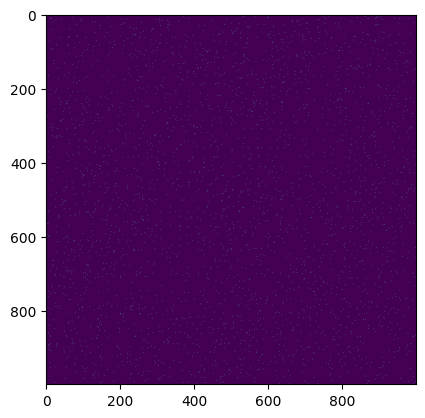

In [64]:
plt.imshow(A1000)

In [49]:
print(triangles(A10),triangles(A100), triangles(A1000))

6 9 7


In [80]:
T = np.zeros(1000)
for i in range(100):
    if i == 0:
        T[i] = 0
    else:
        n = i*10
        p = 3/(n-1)
        A100 = generate(n, 3/(n-1))
        t = triangles(A100)
        T[i] = t

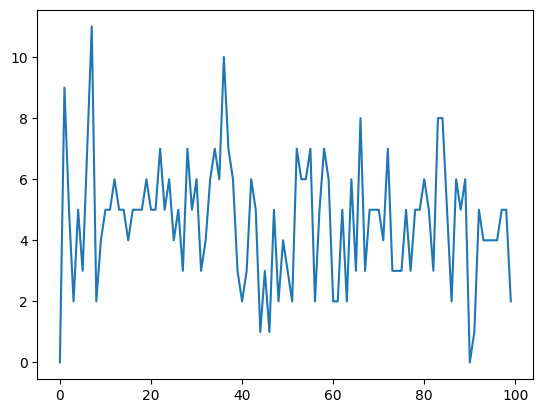

In [84]:
plt.plot(T[:100])

In [97]:
def func(n):
    return scipy.special.factorial(n)/(6*scipy.special.factorial(n-3)) * 27/(n-1)**3

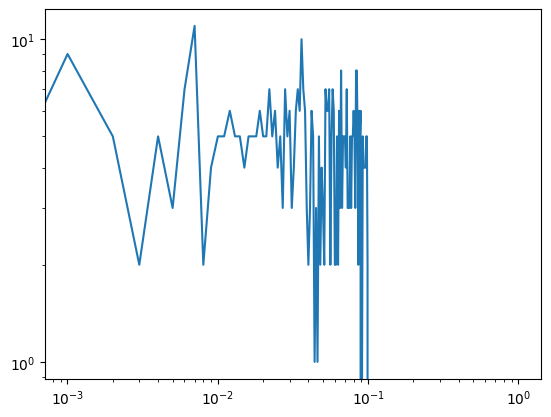

In [91]:
X = np.linspace(0,1,1000)
plt.plot(X,T)
plt.yscale("log")
plt.xscale("log")
plt.show()

Fit: y ≈ 1.59e+05 * x^(--2.99)


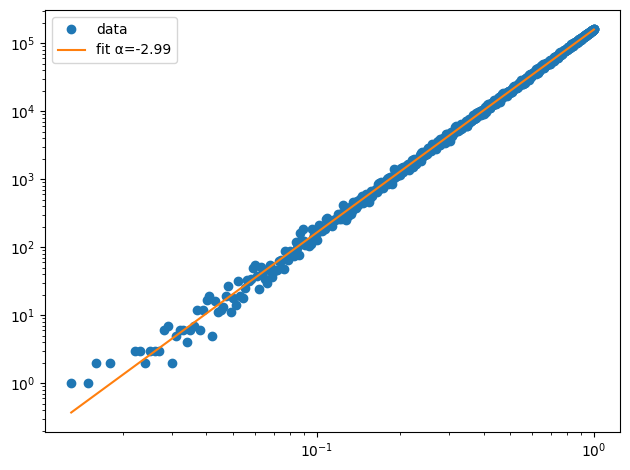

In [79]:
# X, T are your raw data arrays
mask = np.isfinite(X) & np.isfinite(T) & (X > 0) & (T > 0)
x = X[mask]
y = T[mask]

logx = np.log(x)
logy = np.log(y)

# optional: sort by x for a nicer line plot
order = np.argsort(x)
x, y, logx, logy = x[order], y[order], logx[order], logy[order]

# linear fit in log-log space
slope, intercept = np.polyfit(logx, logy, 1)
alpha = -slope
a = np.exp(intercept)
print(f"Fit: y ≈ {a:.3g} * x^(-{alpha:.3g})")

plt.loglog(x, y, 'o', label="data")
plt.loglog(x, a * x**(-alpha), '-', label=f"fit α={alpha:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

In [98]:
X = np.linspace(0,1000,1000,dtype=int)
T_func = func(X)

C:\Users\lucq0\AppData\Local\Temp\ipykernel_1572\156659540.py:2: RuntimeWarning: divide by zero encountered in divide
  return scipy.special.factorial(n)/(6*scipy.special.factorial(n-3)) * 27/(n-1)**3
C:\Users\lucq0\AppData\Local\Temp\ipykernel_1572\156659540.py:2: RuntimeWarning: invalid value encountered in divide
  return scipy.special.factorial(n)/(6*scipy.special.factorial(n-3)) * 27/(n-1)**3


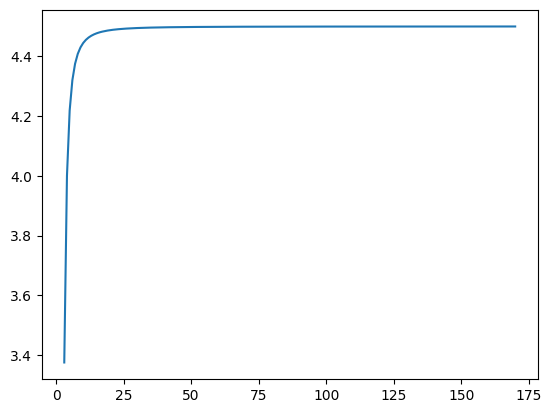

In [99]:
plt.plot(T_func)

In [101]:
A100 = generate(100, 3/(100-1))
G = nx.from_numpy_array(A100)  

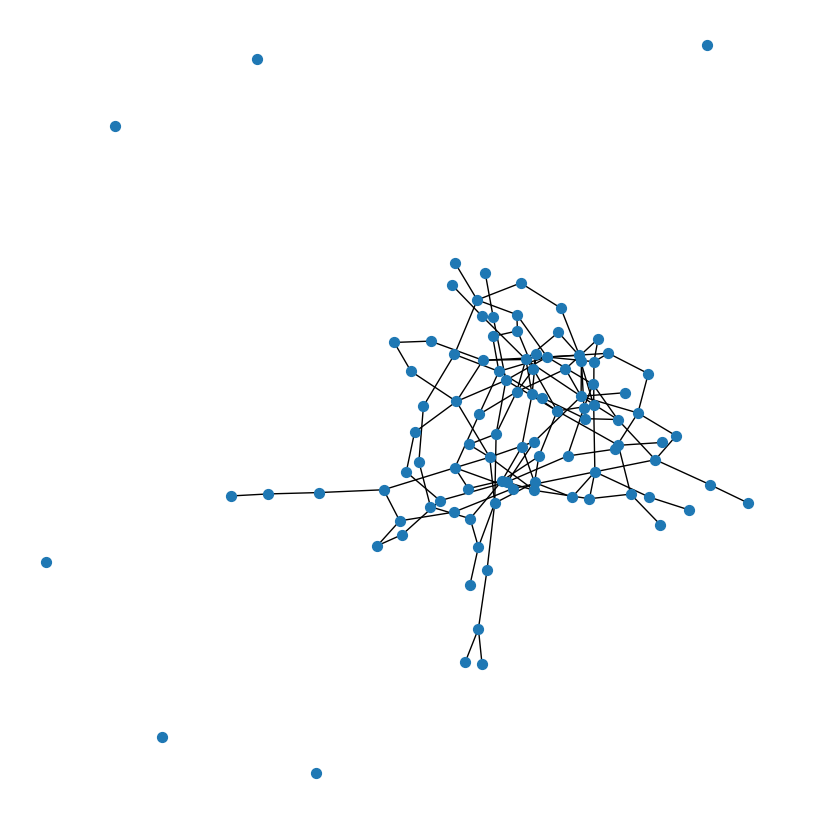

In [102]:
plt.figure(figsize=(8, 8))
nx.draw(G, node_size=50, with_labels=False)
plt.show()


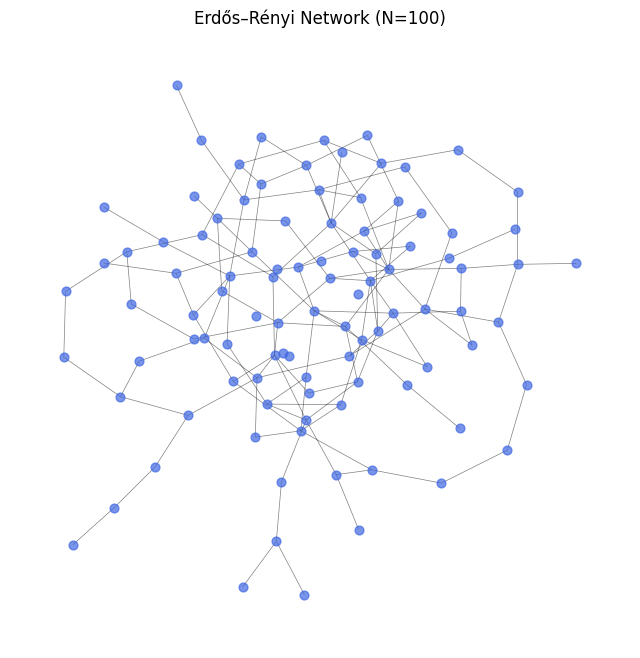

In [105]:
plt.figure(figsize=(8, 8))
pos = nx.kamada_kawai_layout(G)

nx.draw_networkx_nodes(G, pos,
                       node_size=40,
                       node_color="royalblue",
                       alpha=0.7)

nx.draw_networkx_edges(G, pos,
                       width=0.5,
                       alpha=0.5)

plt.axis("off")
plt.title("Erdős–Rényi Network (N=100)")
plt.show()


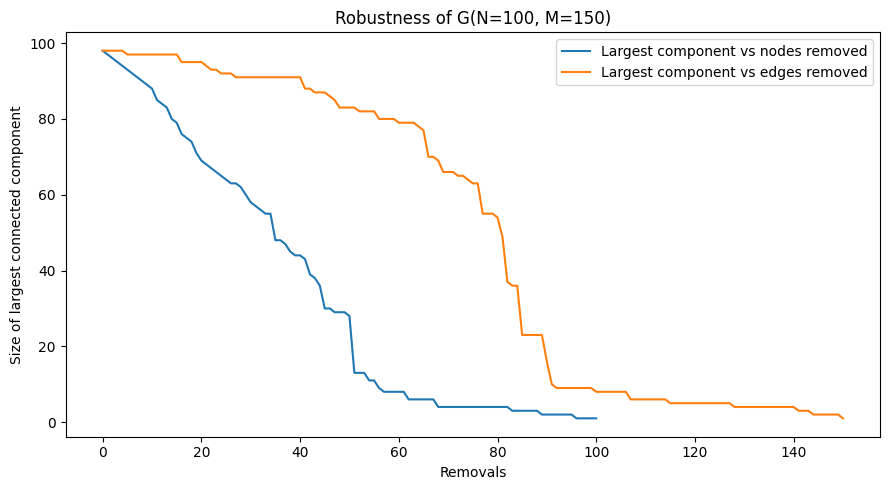

In [134]:
# Parameters
N = 100
M = 150

# Generate undirected ER-like graph with exactly M links
G = nx.gnm_random_graph(N, M)

def largest_cc_size(G_undirected):
    if len(G_undirected) == 0:
        return 0
    return len(max(nx.connected_components(G_undirected), key=len))

# --- Node removal (sequential, random order) ---
G_nodes = G.copy()
node_order = list(G_nodes.nodes())
np.random.shuffle(node_order)

lcc_sizes_nodes = [largest_cc_size(G_nodes)]
for v in node_order:
    G_nodes.remove_node(v)
    lcc_sizes_nodes.append(lcc_sizes_nodes[-1] if len(G_nodes)==0 else largest_cc_size(G_nodes))

# x-axis for node removal is number of nodes removed (0..N)
x_nodes = np.arange(len(lcc_sizes_nodes))

# --- Edge removal (sequential, random order; keep all nodes) ---
G_edges = G.copy()
edge_order = list(G_edges.edges())
np.random.shuffle(edge_order)

lcc_sizes_edges = [largest_cc_size(G_edges)]
for e in edge_order:
    G_edges.remove_edge(*e)
    lcc_sizes_edges.append(largest_cc_size(G_edges))

# x-axis for edge removal is number of edges removed (0..M)
x_edges = np.arange(len(lcc_sizes_edges))

# --- Plot ---
plt.figure(figsize=(9,5))
plt.plot(x_nodes, lcc_sizes_nodes, label="Largest component vs nodes removed")
plt.plot(x_edges, lcc_sizes_edges, label="Largest component vs edges removed")
plt.xlabel("Removals")
plt.ylabel("Size of largest connected component")
plt.title(f"Robustness of G(N={N}, M={M})")
plt.legend()
plt.tight_layout()
plt.show()

## Week 5 Thursday

In [2]:
print(np.random.random())

0.7164536328328792


In [ ]:
def simulation(p = 0.95, n=100000):
    welth = np.array([1], dtype = np.int64)
    total =  1

    for t in range(n):
        if np.random.random() < p:
            idx = np.random.choice(welth.size, p= welth/total)
            welth[idx] += 1
            total += 1
        else:
            welth = np.append(welth,1)
            total += 1
    
    return welth

In [40]:
def wealth_hist_and_tail_fit(wealth, w_min=None):
    """
    From integer wealth array, compute N(w) = number of people with wealth w,
    and fit the tail N(w) ~ C * w^{-alpha} for w >= w_min.
    Returns (w_vals, counts, alpha, C, w_min).
    """
    wealth = np.asarray(wealth, dtype=int)

    # Histogram over integer wealth: index = wealth, value = count
    counts_all = np.bincount(wealth)      
    w_vals = np.arange(counts_all.size)[1:]   # drop wealth=0
    counts = counts_all[1:]

    # Choose a tail threshold if not provided (default: top 5% by wealth)
    if w_min is None:
        w_min = max(2, int(np.percentile(wealth, 95)))

    # Tail selection + filter zeros
    tail_mask = (w_vals >= w_min) & (counts > 0)
    x = np.log(w_vals[tail_mask])
    y = np.log(counts[tail_mask])

    if len(x) < 2:
        raise ValueError("Not enough nonzero tail bins to fit!")

    # Linear fit in log–log space: log N(w) = log C + (-alpha) * log w
    slope, intercept = np.polyfit(x, y, 1)
    alpha = -slope
    C = np.exp(intercept)

    # Plot: histogram counts and fitted tail
    plt.figure()
    plt.loglog(w_vals, counts, 'o', ms=3, label='count N(w)')
    plt.loglog(w_vals[tail_mask], C * w_vals[tail_mask]**(-alpha),
               '-', label=f'fit: α ≈ {alpha:.2f}, w_min={w_min}')
    plt.xlabel('wealth w')
    plt.ylabel('count N(w)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return w_vals, counts, alpha, C, w_min

Final number of people: 1000
Total wealth: 2009 (should be 100001)
Top 5 fortunes: [78, 38, 31, 28, 19]


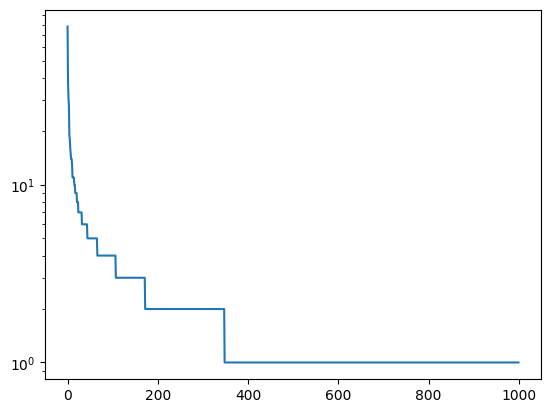

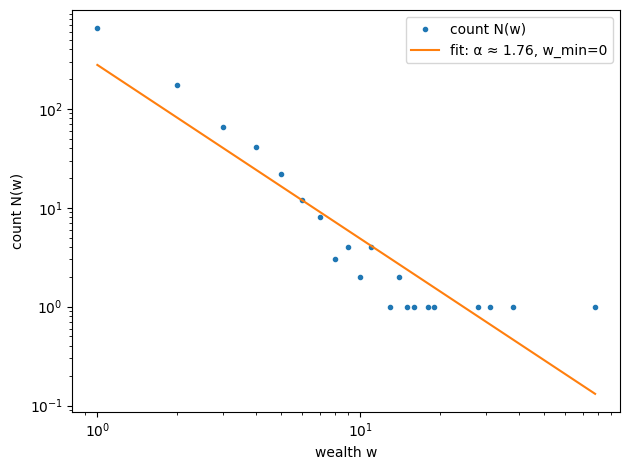

In [60]:
def simulate_simon(p=0.95, T=100_000, seed=None, track=None):
    """
    Herbert Simon (1955) preferential growth / 'rich get richer' model.

    At each step we add $1:
      - with prob p: give it to an existing person chosen with probability
        proportional to their wealth
      - with prob (1-p): create a new person with initial wealth 1

    Args
    ----
    p : float in (0,1)
        Probability of giving to an existing person.
    T : int
        Number of $1 increments (iterations).
    seed : int or None
        RNG seed for reproducibility.
    track : None or dict
        If dict (e.g. {}), will be filled with simple time series like
        number of people and Gini coefficient.

    Returns
    -------
    wealth : np.ndarray, shape (N_people,)
        Final wealths (unsorted, dtype=int).
    """
    if not (0 < p < 1):
        raise ValueError("p must be in (0,1)")
    rng = np.random.default_rng(seed)

    # start with one person holding $1
    wealth = np.array([1], dtype=np.int64)
    total = 1

    if isinstance(track, dict):
        track["t"] = []
        track["N"] = []
        track["gini"] = []

    for t in range(T):
        if rng.random() < p:
            # choose existing person with probability ∝ wealth
            idx = rng.choice(wealth.size, p=wealth / total)
            wealth[idx] += 1
            total += 1
        else:
            wealth = np.append(wealth, 1)
            total += 1
        if len(wealth) > 1000:
            j = np.random.randint(1000)
            total -= wealth[j]
            wealth = np.delete(wealth,j)

        if isinstance(track, dict) and (t % max(1, T // 1000) == 0):
            w = wealth
            # Gini (vectorized; robust for ints)
            if w.size > 0:
                w_sorted = np.sort(w)
                n = w_sorted.size
                cumw = np.cumsum(w_sorted, dtype=np.float64)
                gini = (n + 1 - 2 * (cumw / cumw[-1]).sum()) / n
            else:
                gini = np.nan
            track["t"].append(t + 1)
            track["N"].append(wealth.size)
            track["gini"].append(gini)

    return wealth


p = 0.5        # "rarely give to the poor"
T = 100000     # number of $1 steps
wealth = simulate_simon(p=p, T=T, seed=42)

# Basic summaries
print(f"Final number of people: {wealth.size}")
print(f"Total wealth: {wealth.sum()} (should be {T+1})")
top5 = np.sort(wealth)[-5:][::-1]
print("Top 5 fortunes:", top5.tolist())

# If you want the (rank, wealth) data:
ranks = np.arange(1, wealth.size + 1)
wealth_sorted = np.sort(wealth)[::-1]

plt.plot(wealth_sorted)
plt.yscale("log")
plt.show()
_ = wealth_hist_and_tail_fit(wealth, w_min=0) # set w_min yourself, or leave None




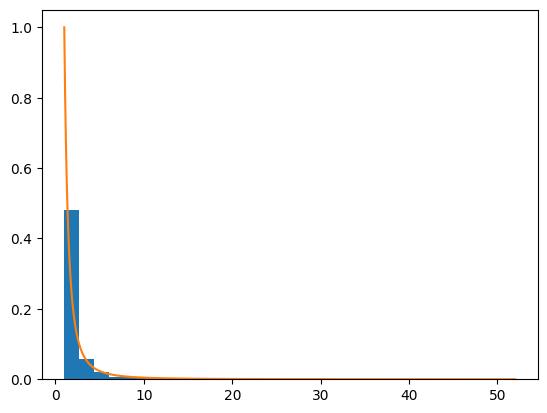

In [42]:
x = np.linspace(min(wealth),max(wealth),1000)
plt.hist(wealth, density = True, bins = 30)
plt.plot(x, 1/x**((2/(2-1/2))+1))
plt.show()


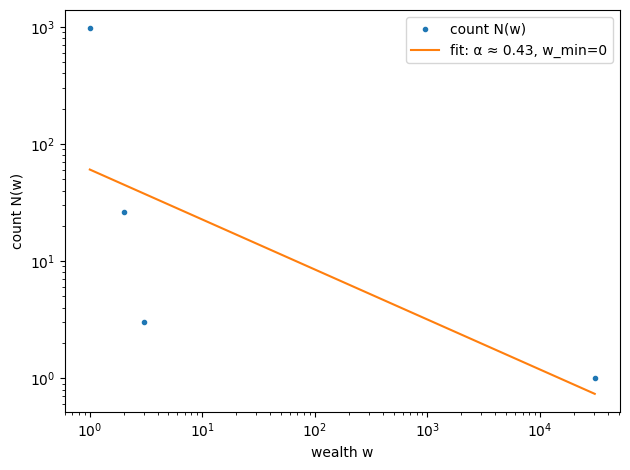

In [51]:
_ = wealth_hist_and_tail_fit(wealth, w_min=0) # set w_min yourself, or leave None